<a href="https://colab.research.google.com/github/LucaWata/Calculo_Numerico/blob/main/Atividade_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aluno(a): Gustavo Jayme Sacramento Buso | RA: 185224 | Turma: IB | Data: 26/08/2026

Aluno(a): Luca Ryuichi Kasai Watanabe | RA: 187465 | Turma: IB | Data: 26/08/2026

# DESCRIÇÃO DO PROBLEMA

Uma equipe está simulando o movimento de um fluido entre duas placas paralelas, separadas por uma distância de H = 0,01 m.<br>
Inicialmente, o fluido está parado. No instante inicial, a placa localizada em y = 0 começa a se mover com velocidade constante U = 1 m/s, enquanto a placa em y = H permanece fixa.<br>
A viscosidade transmite gradualmente o movimento da placa para o interior do fluido.<br>
Contudo, em algumas configurações numéricas, o programa calcula velocidades crescentes e não físicas, até que ocorra overflow.<br>
Desafio: reproduzir a falha, identificar sua causa e testar uma configuração numericamente estável.

#FUNDAMENTAÇÃO TEÓRICA

## 3.1 Representação em um ponto flutuante

Os valores de velocidade são armazenados em números de ponto flutuante, cuja representação pode ser expressa, de forma simplificada, por
$$
x = (−1)^s m^2
$$
e
,
em que $s$ representa o sinal, $m$ o significando e $e$ o expoente. <br>
Como o número de bits é limitado, existe um maior valor finito representável em cada tipo
numérico.

| Tipo numérico | Maior valor finito aproximado |
|:---|---:|
| `float32` | $3,4 \times 10^{38}$ |
| `float64` | $1,8 \times 10^{308}$ |

**O overflow** ocorre quando o resultado de uma operação ultrapassa a faixa representável pelo tipo numérico.
Em operações de ponto flutuante no NumPy, isso pode produzir valores infinitos e avisos de execução. Também é possível configurar o programa para interromper o cálculo ao detectar a falha.
**Atenção:** instabilidade numérica e overflow não são sinônimos. A instabilidade pode amplificar perturbações e erros; o overflow ocorre posteriormente, se alguma operação exceder a capacidade de representação. Uma solução pode estar incorreta muito antes de apresentar overflow.

## 3.2 Modelo físico

Considere um fluido newtoniano, com viscosidade constante, escoamento unidirecional, ausência de gradiente de pressão e ausência de variação ao longo das placas.

Nessas condições, a equação da velocidade é
$$
\frac{∂u}{∂t}
= ν
\frac{∂^2u}{∂y^2}
,
$$

em que:<br>
• $u(y, t)$ é a velocidade paralela às placas, em m/s;<br>
• $y$ é a posição transversal, em $m$;<br>
• $t$ é o tempo, em $s$;<br>
• $v$ é a viscosidade cinemática, em $m^2/s$.<br>
As condições de contorno, para $t$ > 0, são

$$
u(0, t) = U, u(H, t) = 0.
$$

No interior do domínio, a condição inicial é

$$
u(y, 0) = 0, 0 < y < H.
$$

## 3.3 Discretização

Utilizando Euler explícito no tempo e diferenças finitas centrais no espaço:

$$
\frac{u_i^{n+1} - u_i^n}{\Delta t}
=
\nu
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta y^2}.
$$

Isolando a velocidade no próximo instante:

$$
u_i^{n+1}
=
u_i^n
+
r
\left(
u_{i+1}^n - 2u_i^n + u_{i-1}^n
\right)
$$

com

$$
r =
\frac{\nu \Delta t}{\Delta y^2}.
$$

O índice $i$ identifica a posição na malha e o índice $n$ identifica o instante de tempo.

# IMPLEMENTAÇÃO NO GOOGLE COLAB

Neste problema, a velocidade física deve permanecer no intervalo
$$
0 ≤ u(y, t) ≤ U.
$$
Portanto, velocidades muito superiores a 1 m/s já indicam uma solução incorreta, mesmo que não tenha ocorrido overflow.

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


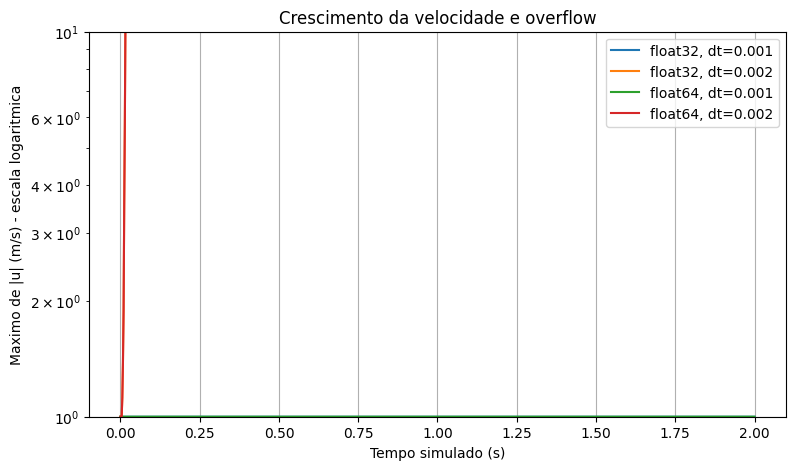

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
  """Simula difusao de velocidade e detecta falhas."""

  H = 0.01
  nu = 1e-4

  y = np.linspace(0, H, pontos)
  dy = H / (pontos - 1)

  # Coeficientes no tipo numerico escolhido.
  r = tipo(nu * dt / dy**2)
  dois = tipo(2)

  # Fluido parado e placa em y=0 em movimento.
  u = np.zeros(pontos, dtype=tipo)
  u[0] = tipo(1)

  tempos = [0.0]
  maximos = [float(np.max(np.abs(u)))]
  falha = None

  # Transforma avisos numericos em excecoes.
  with np.errstate(over="raise", invalid="raise"):
    for passo in range(1, passos + 1):
      try:
        novo = u.copy()

        # Atualiza o interior e preserva as paredes.
        novo[1:-1] = (
            u[1:-1]
            + r * (
                u[2:] - dois * u[1:-1] + u[:-2]
            )
        )

      except FloatingPointError as erro:
        falha = passo
        print(
          f"dt={dt}, {tipo.__name__}: "
          f"falha no passo {passo}, "
          f"t={passo * dt:.4f} s - {erro}"
        )
        break

      u = novo
      tempos.append(passo * dt)
      maximos.append(float(np.max(np.abs(u))))

  if falha is None:
    print(
      f"dt={dt}, {tipo.__name__}: "
      f"{passos} passos sem overflow."
    )

  return {
      "y": y,
      "u": u,
      "tempos": tempos,
      "maximos": maximos,
      "r": float(r),
      "falha": falha,
  }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
  for dt in (0.001, 0.002):
    nome = f"{tipo.__name__}, dt={dt}"
    resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
  plt.semilogy(
    resultado["tempos"],
    resultado["maximos"],
    label=nome
  )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

# ATIVIDADES PROPOSTAS

## 1. Verificação da estabilidade

Calcule $\Delta y, \Delta t_{max}$ e $r$ para os casos A e B. Classifique cada caso como estável ou instável antes de executar o programa. Sendo:<br>
$$
H = 0,01 m;
\nu = 10^{-4}\ \text{m}^2/\text{s};
21 pontos;
\Delta y = 0,0005 m;
$$

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)
    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                novo[1:-1] = u[1:-1] + r * (u[2:] - dois*u[1:-1] + u[:-2])
            except FloatingPointError as erro:
                falha = passo
                print(f"dt={dt}, {tipo.__name__}: falha no passo {passo}, t={passo*dt:.4f}s - {erro}")
                break
            u = novo
            tempos.append(passo*dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")
    return {"y": y, "u": u, "tempos": tempos, "maximos": maximos, "r": float(r), "falha": falha, "dy": dy}

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


## 2. Detecção de overflow

Execute os quatro testes, combinando os dois passos de tempo com os tipos `float32` e `float64`.
Construa uma tabela contendo: tipo numérico, passo de tempo, valor de $r$, ocorrência de overflow e iteração da falha, quando houver.

In [15]:
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo, passos=2000, pontos=21)

linhas = []
for nome, res in resultados.items():
    tipo, dt_s = nome.split(", dt=")
    linhas.append({
        "tipo numerico": tipo,
        "dt (s)": float(dt_s),
        "r": round(res["r"], 3),
        "overflow": "Sim" if res["falha"] else "Nao",
        "passo da falha": res["falha"] if res["falha"] else "-",
        "t da falha": f"{res['falha'] * float(dt):.3f} s" if res["falha"] else "—"
    })
tabela = pd.DataFrame(linhas)
tabela

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340s - overflow encountered in add


,tipo numerico,dt (s),r,overflow,passo da falha,t da falha
0,float32,0.001,0.4,Nao,-,—
1,float32,0.002,0.8,Sim,121,0.242 s
2,float64,0.001,0.4,Nao,-,—
3,float64,0.002,0.8,Sim,917,1.834 s


## 3. Gráfico e interpretação física

Analise o gráfico da maior velocidade em módulo ao longo do tempo. Explique por que o crescimento observado no caso instável não representa o comportamento físico esperado.

/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


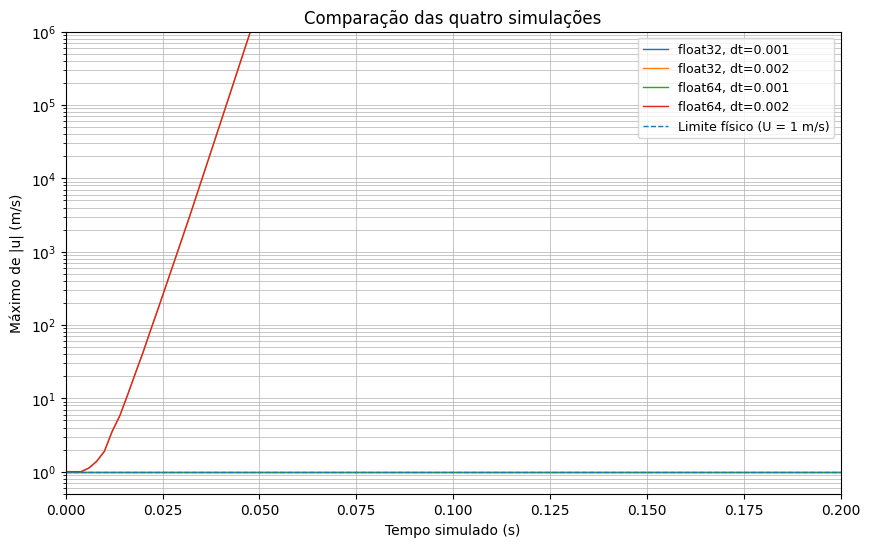

In [16]:
# Atividade 3 - Comparação das quatro simulações

plt.figure(figsize=(10, 6))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome,
        linewidth=1
    )

# Limite físico da velocidade
plt.axhline(
    1,
    linestyle="--",
    linewidth=1,
    label="Limite físico (U = 1 m/s)"
)

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Comparação das quatro simulações")

# Zoom para conseguir visualizar as quatro curvas
plt.xlim(0, 0.20)
plt.ylim(0.5, 1e6)

plt.grid(True, which="both", linewidth=0.5)
plt.legend(fontsize=9)

plt.show()

## 4. Capacidade de representação

Compare os resultados com `float32` e `float64`. A mudança de tipo numérico elimina a instabilidade? Justifique a diferença no número de passos até a falha.

float32 falha no passo 121 e float64 só no passo 917, mas em ambos **r = 0,8** e a taxa de crescimento por passo é idêntica — a instabilidade já existe desde o passo 1 em ambos os casos. A diferença vem apenas do maior valor representável de cada tipo (≈3,4×10³⁸ para float32 contra ≈1,8×10³⁰⁸ para float64): o float64 demora mais passos para os valores crescentes atingirem esse teto. Trocar o tipo numérico **não corrige** a instabilidade, apenas adia — mascara — o momento em que ela se manifesta como overflow.

## 5. Refinamento da malha (41 pontos)

Utilize 41 pontos, passando pontos = 41 para a função, e mantenha inicialmente ∆t = 0,001 s.
Calcule o novo espaçamento e o novo limite de estabilidade. Execute a simulação e explique o resultado.
Em seguida, escolha um passo de tempo abaixo do novo limite e repita o teste.

In [17]:
print("=== Refinamento: pontos=41 ===")
dy41 = 0.01 / (41 - 1)
dtmax41 = dy41**2 / (2 * 1e-4)
print(f"novo dy = {dy41} m")
print(f"novo dt_max = {dtmax41} s")

print("\n-- dt=0,001 (acima do novo limite) --")
res_instavel = simular(0.001, np.float64, passos=2000, pontos=41)

print("\n-- dt=0,0002 (abaixo do novo limite) --")
res_estavel = simular(0.0002, np.float64, passos=5000, pontos=41)

=== Refinamento: pontos=41 ===
novo dy = 0.00025 m
novo dt_max = 0.00031249999999999995 s

-- dt=0,001 (acima do novo limite) --
dt=0.001, float64: falha no passo 426, t=0.4260s - overflow encountered in subtract

-- dt=0,0002 (abaixo do novo limite) --
dt=0.0002, float64: 5000 passos sem overflow.


## 6. Perfil de velocidade vs. solução estacionária

Para uma execução estável e suficientemente longa, represente graficamente o perfil final de velocidade e compare com a solução estacionária:

$$
u_{\mathrm{est}}(y) = U\left(1-\frac{y}{H}\right).
$$

Essa expressão descreve o regime estacionário, e não todo o transiente.

Calcule a diferença máxima em relação ao perfil estacionário:

$$
E_{\infty} =
\max_i
\left|u_i-u_{\mathrm{est}}(y_i)\right|.
$$

Discuta se o tempo simulado foi suficiente para aproximar o regime estacionário. Essa
diferença pode incluir o efeito de um transiente ainda não concluído.

dt=0.001, float64: 2000 passos sem overflow.
E_infinito = 1.605e-09


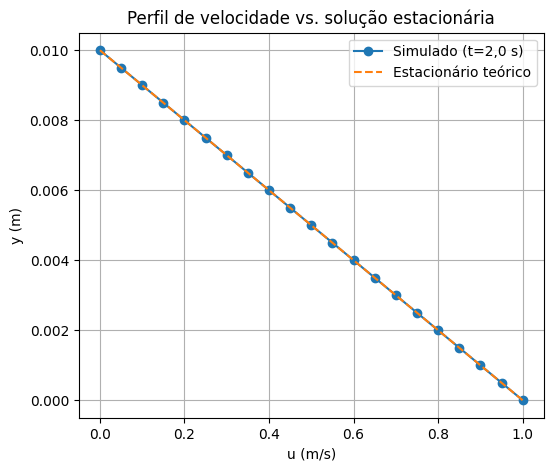

In [18]:
H, U = 0.01, 1.0
res = simular(0.001, np.float64, passos=2000, pontos=21)
y, u_final = res["y"], res["u"]
u_est = U * (1 - y / H)
E_inf = np.max(np.abs(u_final - u_est))
print(f"E_infinito = {E_inf:.3e}")

plt.figure(figsize=(6, 5))
plt.plot(u_final, y, 'o-', label="Simulado (t=2,0 s)")
plt.plot(u_est, y, '--', label="Estacionário teórico")
plt.xlabel("u (m/s)"); plt.ylabel("y (m)")
plt.legend(); plt.grid(True)
plt.title("Perfil de velocidade vs. solução estacionária")
plt.show()

## 7. Conclusão

Explique a relação entre refinamento da malha, passo de tempo, instabilidade numérica e overflow. Indique qual alteração corrigiu a causa da falha nesta simulação.

Refinar a malha (Δy menor) reduz quadraticamente o Δt máximo permitido (Δt_max = Δy²/2ν), portanto malha e passo de tempo não são escolhas independentes no esquema de Euler explícito. A instabilidade numérica surge quando $r$ > 1/2 e é uma propriedade do esquema, não do tipo de dado usado; o overflow é apenas a consequência tardia, quando valores que já crescem exponencialmente ultrapassam o maior valor representável do tipo numérico. Nesta atividade, **a causa da falha foi Δt acima do limite de estabilidade**, e a correção que efetivamente resolveu o problema foi reduzir Δt para manter $r$ ≤ 0,5 — trocar `float32` por `float64` apenas adiou o overflow, sem eliminar a instabilidade.